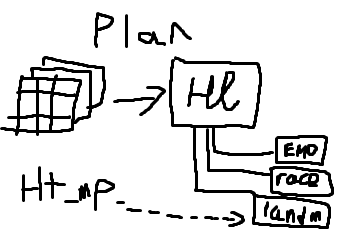
This is my plan. 

##### Load initial lib

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### DF

##### Dataset loading etc.

In [2]:
DATA_DIR = "."
IMG_DIR = os.path.join(DATA_DIR, "RAF/Images/original")
ANNOT_DIR = os.path.join(DATA_DIR, "RAF/Annotations")


In [3]:
label_file = os.path.join(ANNOT_DIR, "list_patition_label.txt")
df_labels = pd.read_csv(label_file, sep=' ', header=None, names=['image', 'emotion'])

In [4]:
manual_dir = os.path.join(ANNOT_DIR, "manual")
manual_data = []

for fname in os.listdir(manual_dir):
    if not fname.endswith(".txt"):
        continue
    path = os.path.join(manual_dir, fname)
    with open(path, 'r') as f:
        lines = f.read().strip().split("\n")
        # First 5 lines: landmarks
        landmarks = [list(map(float, l.split())) for l in lines[:5]]
        # Next 3 lines: gender, race, age
        gender = int(lines[5])
        race = int(lines[6])
        age = int(lines[7])
        manual_data.append({
            'image': fname.replace("_manu_attri.txt", ".jpg"),
            'landmarks_manual': landmarks,
            'gender': gender,
            'race': race,
            'age': age
        })

df_manual = pd.DataFrame(manual_data)

# --- 4. Merge with emotion labels ---
df = df_labels.merge(df_manual, on='image')
df['image_path'] = df['image'].apply(lambda x: os.path.join(IMG_DIR, x))

In [5]:
display(df.head())
print("Total samples:", len(df))

,image,emotion,landmarks_manual,gender,race,age,image_path
0,train_00001.jpg,5,"[[270.17, 330.696], [374.086, 302.67], [325.06...",1,0,2,.\RAF/Images/original\train_00001.jpg
1,train_00002.jpg,5,"[[532.365, 573.652], [753.071, 574.156], [604....",1,0,2,.\RAF/Images/original\train_00002.jpg
2,train_00003.jpg,4,"[[463.469, 554.446], [596.902, 515.023], [472....",1,2,2,.\RAF/Images/original\train_00003.jpg
3,train_00004.jpg,4,"[[296.59, 316.573], [422.501, 318.766], [343.1...",1,0,2,.\RAF/Images/original\train_00004.jpg
4,train_00005.jpg,5,"[[161.18, 181.754], [221.991, 174.016], [201.8...",1,2,1,.\RAF/Images/original\train_00005.jpg


Total samples: 15339


In [6]:
#adding bounding
bbox_dir = os.path.join(ANNOT_DIR, "boundingbox/boundingbox")
bbox_data = []


for fname in os.listdir(bbox_dir):
    if not fname.endswith(".txt"):
        continue
    path = os.path.join(bbox_dir, fname)
    with open(path, 'r') as f:
        line = f.read().strip()
        coords = list(map(float, line.split()))  # [x_min, y_min, x_max, y_max]
        bbox_data.append({
            'image': fname.replace("_boundingbox.txt", ".jpg"),
            'bbox': coords
        })

df_bbox = pd.DataFrame(bbox_data)
display(df_bbox.head())
df = df.merge(df_bbox, on='image')

print("Dataset with bounding boxes loaded:")

,image,bbox
0,test_0001.jpg,"[153.84108, 130.382935, 327.412231, 355.140106]"
1,test_0002.jpg,"[353.7388, 314.479004, 842.010681, 892.362793]"
2,test_0003.jpg,"[215.950302, 200.091782, 365.188934, 414.367676]"
3,test_0004.jpg,"[60.888638, 45.750584, 124.239876, 149.648895]"
4,test_0005.jpg,"[154.699371, 125.201416, 304.901031, 313.391663]"


Dataset with bounding boxes loaded:


In [7]:
df = df[['image', 'emotion', 'race', 'age', 'gender', 'landmarks_manual', 'bbox', 'image_path']]

In [8]:
display(df.head())
print("Total samples:", len(df))

,image,emotion,race,age,gender,landmarks_manual,bbox,image_path
0,train_00001.jpg,5,0,2,1,"[[270.17, 330.696], [374.086, 302.67], [325.06...","[213.92009, 199.133484, 484.330719, 526.302246]",.\RAF/Images/original\train_00001.jpg
1,train_00002.jpg,5,0,2,1,"[[532.365, 573.652], [753.071, 574.156], [604....","[407.148193, 265.544525, 912.439697, 1029.660645]",.\RAF/Images/original\train_00002.jpg
2,train_00003.jpg,4,2,2,1,"[[463.469, 554.446], [596.902, 515.023], [472....","[418.01532, 345.02063, 772.46106, 872.50293]",.\RAF/Images/original\train_00003.jpg
3,train_00004.jpg,4,0,2,1,"[[296.59, 316.573], [422.501, 318.766], [343.1...","[241.747635, 167.216034, 511.343781, 525.823669]",.\RAF/Images/original\train_00004.jpg
4,train_00005.jpg,5,2,1,1,"[[161.18, 181.754], [221.991, 174.016], [201.8...","[114.065239, 113.609695, 249.960373, 281.496063]",.\RAF/Images/original\train_00005.jpg


Total samples: 15339


In [9]:
#train_test count
train_count = df['image'].str.startswith('train_').sum()
test_count = df['image'].str.startswith('test_').sum()
print(f"Train samples: {train_count}")
print(f"Test samples: {test_count}")
print(f"Total counted: {train_count + test_count}  | DataFrame length: {len(df)}")

Train samples: 12271
Test samples: 3068
Total counted: 15339  | DataFrame length: 15339


In [10]:
# del df_labels, df_manual, df_bbox, manual_data, bbox_data, train_count, test_count, fname, path, lines, line, coords
# del gender, race, age, manual_dir, bbox_dir, label_file
# del IMG_DIR, ANNOT_DIR, DATA_DIR, auto_dir, f

In [11]:
df.dtypes
df['gender'] = df['gender'].astype(np.int8)
df['race'] = df['race'].astype(np.int8)
df['age'] = df['age'].astype(np.int8)
df['emotion'] = df['emotion'].astype(np.int8)
df.dtypes

image               object
emotion               int8
race                  int8
age                   int8
gender                int8
landmarks_manual    object
bbox                object
image_path          object
dtype: object

##### csv save

In [2]:
# df.to_pickle("raf_dataset.pkl")
# df = pd.read_pickle("raf_dataset.pkl")
df = pd.read_pickle("raf_dataset.pkl")
df.head()

,image,emotion,race,age,gender,landmarks_manual,bbox,image_path
0,train_00001.jpg,5,0,2,1,"[[270.17, 330.696], [374.086, 302.67], [325.06...","[213.92009, 199.133484, 484.330719, 526.302246]",.\RAF/Images/original\train_00001.jpg
1,train_00002.jpg,5,0,2,1,"[[532.365, 573.652], [753.071, 574.156], [604....","[407.148193, 265.544525, 912.439697, 1029.660645]",.\RAF/Images/original\train_00002.jpg
2,train_00003.jpg,4,2,2,1,"[[463.469, 554.446], [596.902, 515.023], [472....","[418.01532, 345.02063, 772.46106, 872.50293]",.\RAF/Images/original\train_00003.jpg
3,train_00004.jpg,4,0,2,1,"[[296.59, 316.573], [422.501, 318.766], [343.1...","[241.747635, 167.216034, 511.343781, 525.823669]",.\RAF/Images/original\train_00004.jpg
4,train_00005.jpg,5,2,1,1,"[[161.18, 181.754], [221.991, 174.016], [201.8...","[114.065239, 113.609695, 249.960373, 281.496063]",.\RAF/Images/original\train_00005.jpg


##### Data visualization

C:\Users\Niitro_musics\AppData\Local\Temp\ipykernel_5184\412584866.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Niitro_musics\AppData\Local\Temp\ipykernel_5184\412584866.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


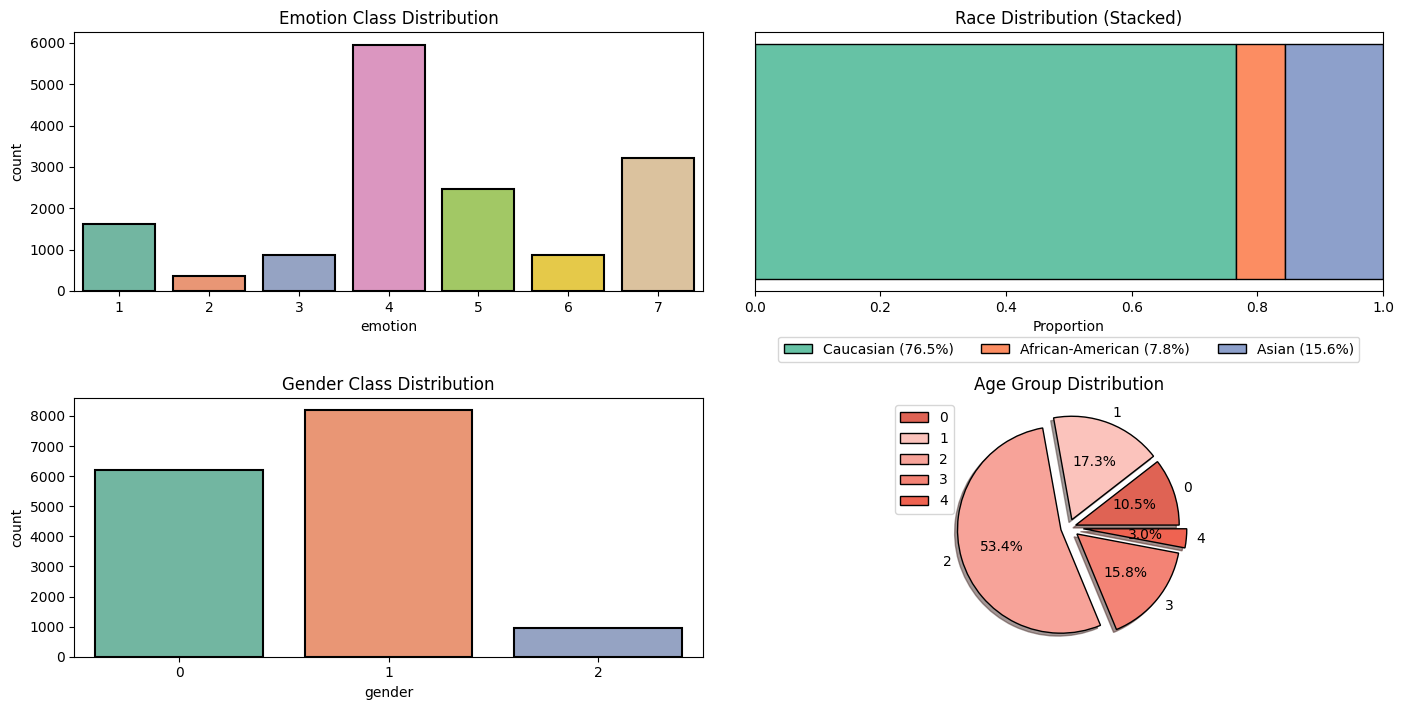

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cols = ['emotion', 'race', 'gender', 'age']
n_cols = 2
n_rows = (len(cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12*1.2, 6*1.2))
axes = axes.flatten()

# Predefine age pie chart settings
agerangeplot_raf = df['age'].value_counts().sort_index().values
agerangelab_raf = [str(i) for i in df['age'].value_counts().sort_index().index]
wedgeprops={'edgecolor': 'black'}

# Get colors from Set2
set2_colors = sns.color_palette('Set2', 8)  # 8 colors in case we need multiple
race_colors = set2_colors[:3]  # first 3 for race
my_old_pallet = ['#df6354','#fbc3bc','#f7a399','#f38375','#ef6351']

for i, col in enumerate(cols):
    if col == 'age':
        # Pie chart for age
        axes[i].pie(
            agerangeplot_raf,
            labels=agerangelab_raf,
            autopct='%1.1f%%',
            colors=my_old_pallet,  # first 5 colors for age
            explode=[0.07,0.08,0.08,0.1,0.14],
            shadow=True,
            wedgeprops=wedgeprops
        )
        axes[i].legend(loc='upper left', bbox_to_anchor=(-0.2, 1))
        axes[i].set_title('Age Group Distribution')
    
    elif col == 'race':
        # Stacked horizontal bar for race with Set2 colors
        race_counts = df['race'].value_counts(normalize=True).sort_index()
        race_labels = ['Caucasian', 'African-American', 'Asian']

        left = 0
        for j, label in enumerate(race_labels):
            axes[i].barh(
                y=0,
                width=race_counts[j],
                left=left,
                color=race_colors[j],
                edgecolor='black',
                height=0.6,
                label=f"{label} ({race_counts[j]*100:.1f}%)"
            )
            left += race_counts[j]

        axes[i].set_xlim(0, 1)
        axes[i].set_yticks([])
        axes[i].set_xlabel("Proportion")
        axes[i].set_title("Race Distribution (Stacked)")
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    else:
        # Bar chart for emotion and gender
        sns.countplot(
            x=col,
            data=df,
            ax=axes[i],
            palette='Set2',
            edgecolor='black',
            linewidth=1.5
        )
        axes[i].set_title(f"{col.capitalize()} Class Distribution")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [3]:
df['emotion'].value_counts().sort_index()

# convert emotion labels to 0-based (1..7 -> 0..6)
df['emotion'] = df['emotion'] - 1

# verify
df['emotion'].value_counts().sort_index()


emotion
0    1619
1     355
2     877
3    5957
4    2460
5     867
6    3204
Name: count, dtype: int64

In [4]:
df_train = df[df['image'].str.startswith('train_')].reset_index(drop=True)
df_test = df[df['image'].str.startswith('test_')].reset_index(drop=True)

C:\Users\Niitro_musics\AppData\Local\Temp\ipykernel_5184\3767061138.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Niitro_musics\AppData\Local\Temp\ipykernel_5184\3767061138.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


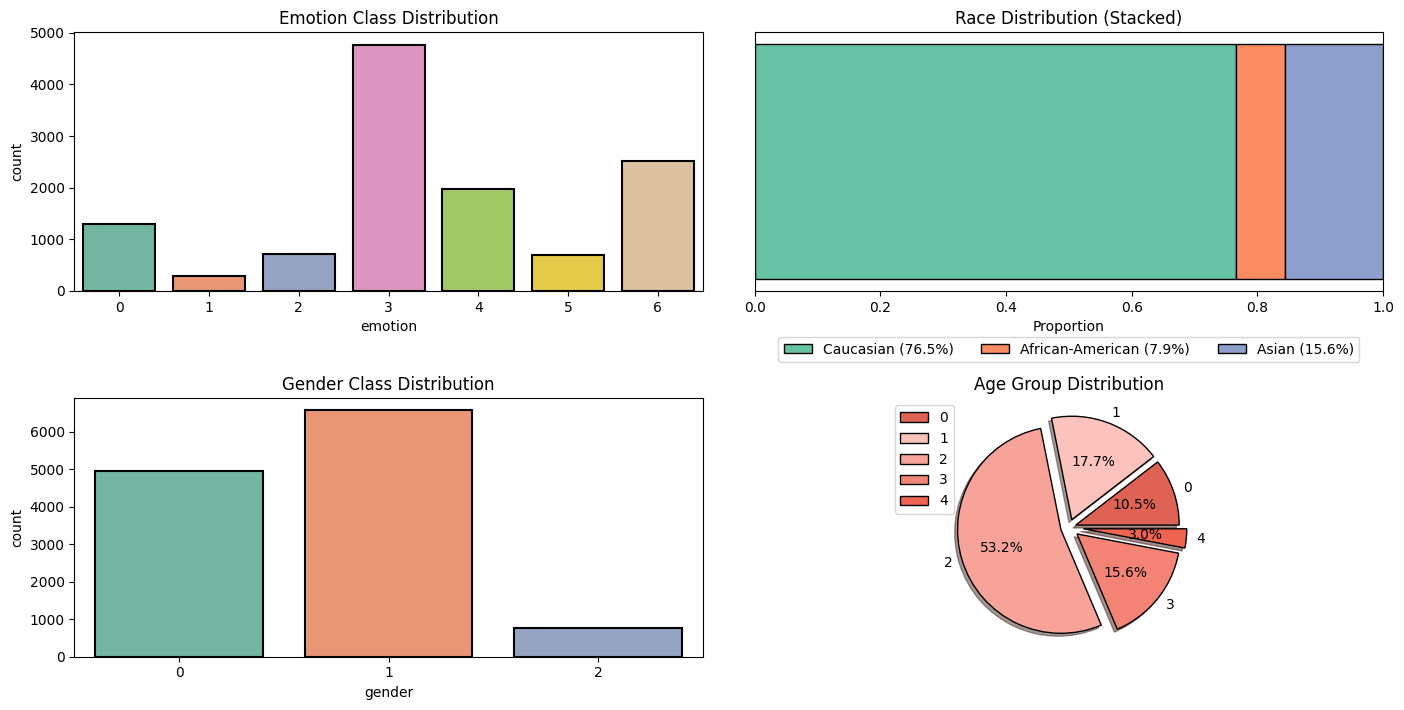

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cols = ['emotion', 'race', 'gender', 'age']
n_cols = 2
n_rows = (len(cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12*1.2, 6*1.2))
axes = axes.flatten()

# Predefine age pie chart settings
agerangeplot_raf = df_train['age'].value_counts().sort_index().values
agerangelab_raf = [str(i) for i in df_train['age'].value_counts().sort_index().index]
wedgeprops={'edgecolor': 'black'}

# Get colors from Set2
set2_colors = sns.color_palette('Set2', 8)  # 8 colors in case we need multiple
race_colors = set2_colors[:3]  # first 3 for race
my_old_pallet = ['#df6354','#fbc3bc','#f7a399','#f38375','#ef6351']

for i, col in enumerate(cols):
    if col == 'age':
        # Pie chart for age
        axes[i].pie(
            agerangeplot_raf,
            labels=agerangelab_raf,
            autopct='%1.1f%%',
            colors=my_old_pallet,  # first 5 colors for age
            explode=[0.07,0.08,0.08,0.1,0.14],
            shadow=True,
            wedgeprops=wedgeprops
        )
        axes[i].legend(loc='upper left', bbox_to_anchor=(-0.2, 1))
        axes[i].set_title('Age Group Distribution')
    
    elif col == 'race':
        # Stacked horizontal bar for race with Set2 colors
        race_counts = df_train['race'].value_counts(normalize=True).sort_index()
        race_labels = ['Caucasian', 'African-American', 'Asian']

        left = 0
        for j, label in enumerate(race_labels):
            axes[i].barh(
                y=0,
                width=race_counts[j],
                left=left,
                color=race_colors[j],
                edgecolor='black',
                height=0.6,
                label=f"{label} ({race_counts[j]*100:.1f}%)"
            )
            left += race_counts[j]

        axes[i].set_xlim(0, 1)
        axes[i].set_yticks([])
        axes[i].set_xlabel("Proportion")
        axes[i].set_title("Race Distribution (Stacked)")
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    else:
        # Bar chart for emotion and gender
        sns.countplot(
            x=col,
            data=df_train,
            ax=axes[i],
            palette='Set2',
            edgecolor='black',
            linewidth=1.5
        )
        axes[i].set_title(f"{col.capitalize()} Class Distribution")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


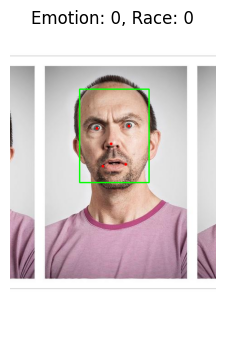

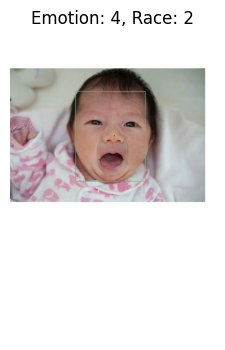

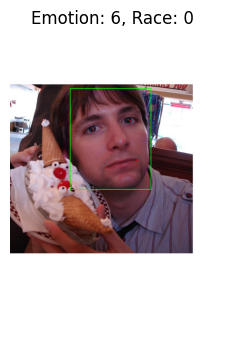

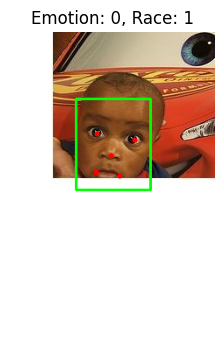

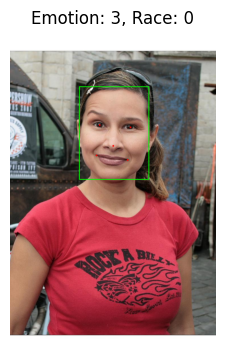

In [6]:
import cv2
import random

def show_image_with_landmarks(row, figsize=(4,4)):
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw bounding box
    x_min, y_min, x_max, y_max = map(int, row['bbox'])
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0,255,0), 2)

    # Draw manual landmarks
    for (x, y) in row['landmarks_manual']:
        cv2.circle(img, (int(x), int(y)), 3, (255,0,0), -1)

    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(f"Emotion: {row['emotion']}, Race: {row['race']}")
    plt.axis('off')
    plt.show()

# Show 5 random samples
for _ in range(5):
    show_image_with_landmarks(df.sample(1).iloc[0])


#### ---- lib

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, mean_squared_error
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F

import keyboard
import cv2

####

#### Models

In [8]:
class MultiTaskCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # --- shared CNN backbone ---
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  # [128,128] -> [128,128]
            nn.ReLU(),
            nn.MaxPool2d(2),                 # -> [64,64]
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # -> [32,32]
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # -> [16,16]
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # -> [8,8]
        )
        
        self.flatten = nn.Flatten()
        self.fc_shared = nn.Linear(256*8*8, 512)
        
        # --- heads ---
        self.head_emotion = nn.Linear(512, 7)   # 7 emotion classes
        self.head_race    = nn.Linear(512, 3)   # 3 races
        self.head_gender  = nn.Linear(512, 3)   # 3 genders
        self.head_age     = nn.Linear(512, 5)   # 5 age ranges
        self.head_landmarks = nn.Linear(512, 10) # 5 landmarks x 2 coords
        
    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = F.relu(self.fc_shared(x))
        
        out = {
            'emotion': self.head_emotion(x),
            'race': self.head_race(x),
            'gender': self.head_gender(x),
            'age': self.head_age(x),
            'landmarks': self.head_landmarks(x).view(-1, 5, 2)
        }
        return out

In [9]:
# model = MultiTaskCNN()  # no .to(device)
# for p in model.parameters():
#     print(p.shape, p.device)

In [10]:
class MultiTaskCNN_v2(nn.Module):
    def __init__(self):
        super().__init__()
        
        # --- shared CNN backbone ---
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 64x64

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8
        )
        
        self.flatten = nn.Flatten()
        self.fc_shared = nn.Linear(256*8*8, 512)
        
        # --- heads ---
        self.head_emotion = nn.Linear(512, 7)   # 7 emotion classes
        self.head_race    = nn.Linear(512, 3)   # 3 races
        self.head_gender  = nn.Linear(512, 3)   # 3 genders
        self.head_age     = nn.Linear(512, 5)   # 5 age ranges
        self.head_landmarks = nn.Linear(512, 10) # 5 landmarks x 2 coords
        
    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = F.relu(self.fc_shared(x))
        
        out = {
            'emotion': self.head_emotion(x),
            'race': self.head_race(x),
            'gender': self.head_gender(x),
            'age': self.head_age(x),
            'landmarks': self.head_landmarks(x).view(-1, 5, 2)
        }
        return out


In [11]:
class MultiTaskCNN_v3(nn.Module):
    def __init__(self):
        super().__init__()
        
        # --- shared CNN backbone ---
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 64x64

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8
        )
        
        self.flatten = nn.Flatten()
        self.fc_shared = nn.Linear(256*8*8, 512)
        self.aaaa = nn.Linear(512, 512)
        # --- heads ---
        self.head_emotion = nn.Linear(512, 7)   # 7 emotion classes
        self.head_race    = nn.Linear(512, 3)   # 3 races
        self.head_gender  = nn.Linear(512, 3)   # 3 genders
        self.head_age     = nn.Linear(512, 5)   # 5 age ranges
        self.head_landmarks = nn.Linear(512, 10) # 5 landmarks x 2 coords
        
    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = F.relu(self.fc_shared(x))
        
        out = {
            'emotion': self.head_emotion(self.aaaa(x)),
            'race': self.head_race(x),
            'gender': self.head_gender(x),
            'age': self.head_age(self.aaaa(x)),
            'landmarks': self.head_landmarks(x).view(-1, 5, 2)
        }
        return out


#### Useful functions

In [12]:
IMG_SIZE = 128
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])
class RAFDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        x_min, y_min, x_max, y_max = map(int, row['bbox'])
        img = img[y_min:y_max, x_min:x_max]
        
        landmarks = torch.tensor(row['landmarks_manual'], dtype=torch.float)
        landmarks[:, 0] -= x_min
        landmarks[:, 1] -= y_min

        if self.transform: 
            img = self.transform(img)
            # If you need landmarks scaled to resized image:
            h, w = img.shape[1:]  # after ToTensor, shape is [C,H,W]
            orig_h, orig_w = y_max - y_min, x_max - x_min
            scale_x = w / orig_w
            scale_y = h / orig_h
            landmarks[:, 0] *= scale_x
            landmarks[:, 1] *= scale_y

        targets = {
            'emotion': torch.tensor(row['emotion'], dtype=torch.long),
            'race': torch.tensor(row['race'], dtype=torch.long),
            'gender': torch.tensor(row['gender'], dtype=torch.long),
            'age': torch.tensor(row['age'], dtype=torch.long),
            'landmarks': landmarks,
        }

        return img, targets


In [13]:
def eval_model(model, df_test, transform, device='cuda'):
    model.eval()

    test_data = RAFDataset(df_test, transform=transform)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

    all_emotion_preds, all_emotion_true = [], []
    all_race_preds, all_race_true = [], []
    all_gender_preds, all_gender_true = [], []
    all_age_preds, all_age_true = [], []
    all_landmarks_pred, all_landmarks_true = [], []

    with torch.no_grad():
        for imgs, targets in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)

            # --- predictions ---
            preds_emotion = outputs['emotion'].argmax(dim=1).cpu()
            preds_race    = outputs['race'].argmax(dim=1).cpu()
            preds_gender  = outputs['gender'].argmax(dim=1).cpu()
            preds_age     = outputs['age'].argmax(dim=1).cpu()
            preds_landmarks = outputs['landmarks'].cpu()

            # --- collect ---
            all_emotion_preds.extend(preds_emotion)
            all_emotion_true.extend(targets['emotion'])
            all_race_preds.extend(preds_race)
            all_race_true.extend(targets['race'])
            all_gender_preds.extend(preds_gender)
            all_gender_true.extend(targets['gender'])
            all_age_preds.extend(preds_age)
            all_age_true.extend(targets['age'])
            all_landmarks_pred.append(preds_landmarks)
            all_landmarks_true.append(targets['landmarks'])

    # --- convert lists to tensors ---
    all_emotion_preds = torch.stack(all_emotion_preds)
    all_emotion_true  = torch.stack(all_emotion_true)
    all_race_preds = torch.stack(all_race_preds)
    all_race_true  = torch.stack(all_race_true)
    all_gender_preds = torch.stack(all_gender_preds)
    all_gender_true  = torch.stack(all_gender_true)
    all_age_preds = torch.stack(all_age_preds)
    all_age_true  = torch.stack(all_age_true)
    all_landmarks_pred = torch.cat(all_landmarks_pred)
    all_landmarks_true = torch.cat(all_landmarks_true)

    # --- compute metrics ---
    emotion_acc = accuracy_score(all_emotion_true, all_emotion_preds)
    race_acc    = accuracy_score(all_race_true, all_race_preds)
    gender_acc  = accuracy_score(all_gender_true, all_gender_preds)
    age_acc     = accuracy_score(all_age_true, all_age_preds)
    land_mse    = mean_squared_error(
        all_landmarks_true.reshape(-1, 10),
        all_landmarks_pred.reshape(-1, 10)
    )

    print(f"Emotion Accuracy: {emotion_acc:.4f}")
    print(f"Race Accuracy:    {race_acc:.4f}")
    print(f"Gender Accuracy:  {gender_acc:.4f}")
    print(f"Age Accuracy:     {age_acc:.4f}")
    print(f"Landmarks MSE:    {land_mse:.6f}")


In [14]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.2),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [15]:
def emotion_label_to_text(label):
    labels = {
        0: "Surprise",
        1: "Fear",
        2: "Disgust",
        3: "Happiness",
        4: "Sadness",
        5: "Anger",
        6: "Neutral"
    }
    return labels.get(label, "Unknown")
def age_label_to_text(label):
    labels = {
        0: "0-3",
        1: "4-19",
        2: "20-39",
        3: "40-69",
        4: "70+"
    }
    return labels.get(label, "Unknown")
def race_label_to_text(label):
    labels = {
        0: "Caucasian",
        1: "African-American",
        2: "Asian"
    }
    return labels.get(label, "Unknown")
def gender_label_to_text(label):
    labels = {
        0: "Male",
        1: "Female",
        2: "Unsure"
    }
    return labels.get(label, "Unknown")

#### Attempt 1

##### Model initials

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [106]:
# class_weights = {}
# for col in cols:
#     counts = df[col].value_counts().sort_index()
#     weights = 1.0 / counts
#     # normalize
#     weights = weights / weights.sum() * len(counts)
#     class_weights[col] = torch.tensor(weights.values, dtype=torch.float)
    
# print("Class weights per column:")
# for col, w in class_weights.items():
#     print(f"{col}: {w}")

In [109]:
# def collate_fn(batch):
#     imgs = torch.stack([item[0] for item in batch])
#     targets = {
#         'emotion': torch.tensor([item[1]['emotion'] for item in batch], dtype=torch.long),  # shift to 0-based
#         'race': torch.tensor([item[1]['race'] for item in batch], dtype=torch.long),
#         'gender': torch.tensor([item[1]['gender'] for item in batch], dtype=torch.long),
#         'age': torch.tensor([item[1]['age'] for item in batch], dtype=torch.long),
#         'landmarks': torch.stack([item[1]['landmarks'] for item in batch])
#     }
#     return imgs, targets

In [17]:
dataset = RAFDataset(df_train, transform=transform)

In [18]:
class_counts = df_train['emotion'].value_counts().sort_index().values
weights = 1. / torch.tensor(class_counts, dtype=torch.float)

# shift to 0-based index
sample_weights = weights[df_train['emotion'].values - 1]  

sampler = WeightedRandomSampler(
    sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)


In [19]:
dataloader = DataLoader(dataset, batch_size=32, sampler=sampler)

# Test: fetch one batch
for images, targets in dataloader:
    print(images.shape)
    print(targets)
    break

torch.Size([32, 3, 128, 128])
{'emotion': tensor([6, 6, 2, 3, 6, 3, 5, 3, 2, 4, 2, 2, 4, 3, 3, 6, 6, 3, 3, 4, 3, 4, 6, 6,
        6, 3, 4, 2, 3, 3, 6, 3]), 'race': tensor([2, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2,
        0, 0, 0, 1, 2, 2, 0, 1]), 'gender': tensor([1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 0,
        2, 0, 1, 0, 1, 1, 1, 1]), 'age': tensor([1, 0, 1, 0, 0, 3, 2, 2, 3, 4, 2, 1, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 1, 2,
        0, 0, 1, 2, 1, 2, 2, 1]), 'landmarks': tensor([[[ 24.0640,  54.5340],
         [ 80.3631,  49.4040],
         [ 43.9040,  68.0820],
         [ 30.4980,  99.6900],
         [ 72.0509,  98.8680]],

        [[ 38.4368,  64.1658],
         [100.6448,  65.3427],
         [ 66.3857,  84.5594],
         [ 48.3538, 101.6192],
         [ 83.7400, 102.9914]],

        [[ 42.0637,  49.8858],
         [101.1987,  47.2824],
         [ 73.1517,  76.0324],
         [ 49.1550, 103.2653],
         [ 94.1896, 100.55

##### Model 1

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
model = MultiTaskCNN().to(device)

criterion_cls = nn.CrossEntropyLoss()  # for emotion, race, gender, age
criterion_land = nn.MSELoss()          # for landmarks

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Using device: cuda


In [21]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    
    for imgs, targets in dataloader:
        imgs = imgs.to(device)
        emotions = targets['emotion'].to(device)
        races    = targets['race'].to(device)
        genders  = targets['gender'].to(device)
        ages     = targets['age'].to(device)
        landmarks = targets['landmarks'].to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        
        # --- compute losses ---
        loss_emotion = criterion_cls(outputs['emotion'], emotions)
        loss_race    = criterion_cls(outputs['race'], races)
        loss_gender  = criterion_cls(outputs['gender'], genders)
        loss_age     = criterion_cls(outputs['age'], ages)
        loss_land    = criterion_land(outputs['landmarks'], landmarks)
        
        # --- total loss ---
        loss = loss_emotion + loss_race + loss_gender + loss_age + loss_land
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {total_loss/len(dataloader):.4f}")

Epoch [1/10] | Loss: 278.9902
Epoch [2/10] | Loss: 166.1933
Epoch [3/10] | Loss: 73.6245
Epoch [4/10] | Loss: 56.3037
Epoch [5/10] | Loss: 50.7520
Epoch [6/10] | Loss: 43.4509
Epoch [7/10] | Loss: 42.6194
Epoch [8/10] | Loss: 38.3786
Epoch [9/10] | Loss: 33.8755
Epoch [10/10] | Loss: 33.9276


In [22]:


model.eval()

test_data = RAFDataset(df_test, transform=transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

all_emotion_preds, all_emotion_true = [], []
all_race_preds, all_race_true = [], []
all_gender_preds, all_gender_true = [], []
all_age_preds, all_age_true = [], []
all_landmarks_pred, all_landmarks_true = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)

        # --- predictions ---
        preds_emotion = outputs['emotion'].argmax(dim=1).cpu()
        preds_race    = outputs['race'].argmax(dim=1).cpu()
        preds_gender  = outputs['gender'].argmax(dim=1).cpu()
        preds_age     = outputs['age'].argmax(dim=1).cpu()
        preds_landmarks = outputs['landmarks'].cpu()

        # --- collect ---
        all_emotion_preds.extend(preds_emotion)
        all_emotion_true.extend(targets['emotion'])
        all_race_preds.extend(preds_race)
        all_race_true.extend(targets['race'])
        all_gender_preds.extend(preds_gender)
        all_gender_true.extend(targets['gender'])
        all_age_preds.extend(preds_age)
        all_age_true.extend(targets['age'])
        all_landmarks_pred.append(preds_landmarks)
        all_landmarks_true.append(targets['landmarks'])

# --- convert lists to tensors ---
all_emotion_preds = torch.stack(all_emotion_preds)
all_emotion_true  = torch.stack(all_emotion_true)
all_race_preds = torch.stack(all_race_preds)
all_race_true  = torch.stack(all_race_true)
all_gender_preds = torch.stack(all_gender_preds)
all_gender_true  = torch.stack(all_gender_true)
all_age_preds = torch.stack(all_age_preds)
all_age_true  = torch.stack(all_age_true)
all_landmarks_pred = torch.cat(all_landmarks_pred)
all_landmarks_true = torch.cat(all_landmarks_true)

# --- compute metrics ---
emotion_acc = accuracy_score(all_emotion_true, all_emotion_preds)
race_acc    = accuracy_score(all_race_true, all_race_preds)
gender_acc  = accuracy_score(all_gender_true, all_gender_preds)
age_acc     = accuracy_score(all_age_true, all_age_preds)
land_mse    = mean_squared_error(
    all_landmarks_true.reshape(-1, 10),
    all_landmarks_pred.reshape(-1, 10)
)

print(f"Emotion Accuracy: {emotion_acc:.4f}")
print(f"Race Accuracy:    {race_acc:.4f}")
print(f"Gender Accuracy:  {gender_acc:.4f}")
print(f"Age Accuracy:     {age_acc:.4f}")
print(f"Landmarks MSE:    {land_mse:.6f}")


Emotion Accuracy: 0.5326
Race Accuracy:    0.6933
Gender Accuracy:  0.6519
Age Accuracy:     0.5981
Landmarks MSE:    35.310158


In [23]:
def train_model(model, dataloader, epochs):
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        model.train()
        total_loss = 0.0
        for imgs, targets in dataloader:
            imgs = imgs.to(device)
            emotions = targets['emotion'].to(device)
            races    = targets['race'].to(device)
            genders  = targets['gender'].to(device)
            ages     = targets['age'].to(device)
            landmarks = targets['landmarks'].to(device)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            
            loss_emotion = criterion_cls(outputs['emotion'], emotions)
            loss_race    = criterion_cls(outputs['race'], races)
            loss_gender  = criterion_cls(outputs['gender'], genders)
            loss_age     = criterion_cls(outputs['age'], ages)
            loss_land    = criterion_land(outputs['landmarks'], landmarks)
            
            # --- total loss ---
            loss = loss_emotion + loss_race + loss_gender + loss_age + loss_land
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
    
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {total_loss/len(dataloader):.4f}")
    return model

In [24]:
model2 = train_model(model, dataloader, 20)

Epoch 1/20
Epoch [1/20] | Loss: 30.0338
Epoch 2/20
Epoch [2/20] | Loss: 27.6960
Epoch 3/20
Epoch [3/20] | Loss: 27.2372
Epoch 4/20
Epoch [4/20] | Loss: 25.2189
Epoch 5/20
Epoch [5/20] | Loss: 23.5152
Epoch 6/20
Epoch [6/20] | Loss: 22.0883
Epoch 7/20
Epoch [7/20] | Loss: 20.8210
Epoch 8/20
Epoch [8/20] | Loss: 18.3950
Epoch 9/20
Epoch [9/20] | Loss: 17.0834
Epoch 10/20
Epoch [10/20] | Loss: 16.1337
Epoch 11/20
Epoch [11/20] | Loss: 14.8462
Epoch 12/20
Epoch [12/20] | Loss: 13.6370
Epoch 13/20
Epoch [13/20] | Loss: 12.4022
Epoch 14/20
Epoch [14/20] | Loss: 11.6764
Epoch 15/20
Epoch [15/20] | Loss: 11.5434
Epoch 16/20
Epoch [16/20] | Loss: 10.4436
Epoch 17/20
Epoch [17/20] | Loss: 9.7024
Epoch 18/20
Epoch [18/20] | Loss: 9.2561
Epoch 19/20
Epoch [19/20] | Loss: 8.6533
Epoch 20/20
Epoch [20/20] | Loss: 8.1120


In [25]:
eval_model(model, df_test, transform)

Emotion Accuracy: 0.5896
Race Accuracy:    0.7979
Gender Accuracy:  0.7383
Age Accuracy:     0.6167
Landmarks MSE:    22.426504


##### Model 2

In [ ]:
train_data = RAFDataset(df_train, transform=train_transform)

class_counts = df_train['emotion'].value_counts().sort_index().values
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = weights[df_train['emotion'].values]  
sampler = WeightedRandomSampler(
    sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True)

dataloader = DataLoader(train_data, batch_size=32, sampler=sampler)

In [ ]:
race_counts = df_train['race'].value_counts().sort_index().values
race_weights = 1. / torch.tensor(race_counts, dtype=torch.float)
race_weights = race_weights / race_weights.sum()
criterion_race = nn.CrossEntropyLoss(weight=race_weights.to(device))

gender_counts = df_train['gender'].value_counts().sort_index().values
gender_weights = 1. / torch.tensor(gender_counts, dtype=torch.float)
gender_weights = gender_weights / gender_weights.sum()
criterion_gender = nn.CrossEntropyLoss(weight=gender_weights.to(device))

age_counts = df_train['age'].value_counts().sort_index().values
age_weights = 1. / torch.tensor(age_counts, dtype=torch.float)
age_weights = age_weights / age_weights.sum()
criterion_age = nn.CrossEntropyLoss(weight=age_weights.to(device))


In [97]:
print("Using device:", device)
try: del model2
except: print("model2 not defined, continuing...")
model2 = MultiTaskCNN().to(device)

criterion_land = nn.MSELoss()

optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)


Using device: cuda


In [98]:
def train_model(model, dataloader, epochs):
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        model.train()
        total_loss = 0.0
        for imgs, targets in dataloader:
            imgs = imgs.to(device)
            emotions = targets['emotion'].to(device)
            races    = targets['race'].to(device)
            genders  = targets['gender'].to(device)
            ages     = targets['age'].to(device)
            landmarks = targets['landmarks'].to(device)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            
            loss_emotion = criterion_cls(outputs['emotion'], emotions)
            loss_race    = criterion_cls(outputs['race'], races)
            loss_gender  = criterion_cls(outputs['gender'], genders)
            loss_age     = criterion_cls(outputs['age'], ages)
            loss_land    = criterion_land(outputs['landmarks'], landmarks)
            
            # --- total loss ---
            loss = loss_emotion + loss_race + loss_gender + loss_age + loss_land
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
    
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {total_loss/len(dataloader):.4f}")
    return model

In [99]:
train_model(model2, dataloader, 10)

eval_model(model2, df_test, test_transform)

Epoch 1/10
Epoch [1/10] | Loss: 321.4982
Epoch 2/10
Epoch [2/10] | Loss: 178.3377
Epoch 3/10
Epoch [3/10] | Loss: 112.1248
Epoch 4/10
Epoch [4/10] | Loss: 67.8698
Epoch 5/10
Epoch [5/10] | Loss: 57.2631
Epoch 6/10
Epoch [6/10] | Loss: 49.3401
Epoch 7/10
Epoch [7/10] | Loss: 46.6841
Epoch 8/10
Epoch [8/10] | Loss: 42.2155
Epoch 9/10
Epoch [9/10] | Loss: 37.2315
Epoch 10/10
Epoch [10/10] | Loss: 35.0253
Emotion Accuracy: 0.4987
Race Accuracy:    0.7637
Gender Accuracy:  0.6134
Age Accuracy:     0.6232
Landmarks MSE:    36.692528


In [100]:
train_model(model2, dataloader, 30)

eval_model(model2, df_test, test_transform)

Epoch 1/30
Epoch [1/30] | Loss: 32.2081
Epoch 2/30
Epoch [2/30] | Loss: 29.9128
Epoch 3/30
Epoch [3/30] | Loss: 26.2962
Epoch 4/30
Epoch [4/30] | Loss: 23.9888
Epoch 5/30
Epoch [5/30] | Loss: 20.4400
Epoch 6/30
Epoch [6/30] | Loss: 19.8551
Epoch 7/30
Epoch [7/30] | Loss: 19.8539
Epoch 8/30
Epoch [8/30] | Loss: 16.2438
Epoch 9/30
Epoch [9/30] | Loss: 15.9688
Epoch 10/30
Epoch [10/30] | Loss: 15.4134
Epoch 11/30
Epoch [11/30] | Loss: 13.2519
Epoch 12/30
Epoch [12/30] | Loss: 11.8144
Epoch 13/30
Epoch [13/30] | Loss: 10.4463
Epoch 14/30
Epoch [14/30] | Loss: 10.5560
Epoch 15/30
Epoch [15/30] | Loss: 9.0911
Epoch 16/30
Epoch [16/30] | Loss: 8.2411
Epoch 17/30
Epoch [17/30] | Loss: 7.6844
Epoch 18/30
Epoch [18/30] | Loss: 7.1411
Epoch 19/30
Epoch [19/30] | Loss: 7.7771
Epoch 20/30
Epoch [20/30] | Loss: 6.6126
Epoch 21/30
Epoch [21/30] | Loss: 6.4361
Epoch 22/30
Epoch [22/30] | Loss: 5.6870
Epoch 23/30
Epoch [23/30] | Loss: 5.1305
Epoch 24/30
Epoch [24/30] | Loss: 5.2182
Epoch 25/30
Epoch [2

In [102]:
print("Using device:", device)
model3 = MultiTaskCNN().to(device)

criterion_land = nn.MSELoss()

optimizer = torch.optim.Adam(model3.parameters(), lr=1e-3)



def train_model3(model, dataloader, epochs):
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        model.train()
        total_loss = 0.0
        for imgs, targets in dataloader:
            imgs = imgs.to(device)
            emotions = targets['emotion'].to(device)
            races    = targets['race'].to(device)
            genders  = targets['gender'].to(device)
            ages     = targets['age'].to(device)
            landmarks = targets['landmarks'].to(device)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            
            loss_emotion = criterion_cls(outputs['emotion'], emotions)
            loss_race    = criterion_race(outputs['race'], races)
            loss_gender  = criterion_gender(outputs['gender'], genders)
            loss_age     = criterion_age(outputs['age'], ages)
            loss_land    = criterion_land(outputs['landmarks'], landmarks)
            
            # --- total loss ---
            loss = loss_emotion + loss_race + loss_gender + loss_age + loss_land
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
    
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {total_loss/len(dataloader):.4f}")
    return model

train_model3(model3, dataloader, 30)
eval_model(model3, df_test, test_transform)

Using device: cuda
Epoch 1/30
Epoch [1/30] | Loss: 373.6639
Epoch 2/30
Epoch [2/30] | Loss: 180.1819
Epoch 3/30
Epoch [3/30] | Loss: 134.8783
Epoch 4/30
Epoch [4/30] | Loss: 74.2462
Epoch 5/30
Epoch [5/30] | Loss: 61.8625
Epoch 6/30
Epoch [6/30] | Loss: 55.5833
Epoch 7/30
Epoch [7/30] | Loss: 52.2530
Epoch 8/30
Epoch [8/30] | Loss: 48.3045
Epoch 9/30
Epoch [9/30] | Loss: 46.0235
Epoch 10/30
Epoch [10/30] | Loss: 40.1589
Epoch 11/30
Epoch [11/30] | Loss: 38.8852
Epoch 12/30
Epoch [12/30] | Loss: 33.6256
Epoch 13/30
Epoch [13/30] | Loss: 31.4142
Epoch 14/30
Epoch [14/30] | Loss: 29.1767
Epoch 15/30
Epoch [15/30] | Loss: 26.5889
Epoch 16/30
Epoch [16/30] | Loss: 24.4043
Epoch 17/30
Epoch [17/30] | Loss: 22.0602
Epoch 18/30
Epoch [18/30] | Loss: 19.7539
Epoch 19/30
Epoch [19/30] | Loss: 18.7190
Epoch 20/30
Epoch [20/30] | Loss: 16.9431
Epoch 21/30
Epoch [21/30] | Loss: 14.8402
Epoch 22/30
Epoch [22/30] | Loss: 13.3420
Epoch 23/30
Epoch [23/30] | Loss: 12.4665
Epoch 24/30
Epoch [24/30] | Lo

#### THE CELL ABOVE SHOULD BE DONE AND SHOULD SHOW MSE FOR LANDMARKS AT THE END. Close my laptop after it is done

In [117]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    
    for imgs, targets in dataloader:
        imgs = imgs.to(device)
        emotions = targets['emotion'].to(device)
        races    = targets['race'].to(device)
        genders  = targets['gender'].to(device)
        ages     = targets['age'].to(device)
        landmarks = targets['landmarks'].to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        
        # --- compute losses ---
        loss_emotion = criterion_cls(outputs['emotion'], emotions)
        loss_race    = criterion_cls(outputs['race'], races)
        loss_gender  = criterion_cls(outputs['gender'], genders)
        loss_age     = criterion_cls(outputs['age'], ages)
        loss_land    = criterion_land(outputs['landmarks'], landmarks)
        
        # --- total loss ---
        loss = loss_emotion + loss_race + loss_gender + loss_age + loss_land
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {total_loss/len(dataloader):.4f}")

Epoch [1/20] | Loss: 299.9055
Epoch [2/20] | Loss: 162.2645
Epoch [3/20] | Loss: 80.0994
Epoch [4/20] | Loss: 57.5191
Epoch [5/20] | Loss: 48.9340
Epoch [6/20] | Loss: 47.1187
Epoch [7/20] | Loss: 43.0825
Epoch [8/20] | Loss: 42.2239
Epoch [9/20] | Loss: 35.3600
Epoch [10/20] | Loss: 33.3346
Epoch [11/20] | Loss: 32.4943
Epoch [12/20] | Loss: 28.2448
Epoch [13/20] | Loss: 25.6119
Epoch [14/20] | Loss: 24.5480
Epoch [15/20] | Loss: 22.3305
Epoch [16/20] | Loss: 20.9580
Epoch [17/20] | Loss: 18.7918
Epoch [18/20] | Loss: 15.9243
Epoch [19/20] | Loss: 15.2729
Epoch [20/20] | Loss: 13.8278


In [119]:
eval_model(model, df_test, transform)

Emotion Accuracy: 0.5792
Race Accuracy:    0.7767
Gender Accuracy:  0.6855
Age Accuracy:     0.6555
Landmarks MSE:    26.237507


In [120]:
train_model(model, dataloader, 10)

Epoch 1/10
Epoch [1/10] | Loss: 12.4577
Epoch 2/10
Epoch [2/10] | Loss: 11.7008
Epoch 3/10
Epoch [3/10] | Loss: 11.9753
Epoch 4/10
Epoch [4/10] | Loss: 10.6528
Epoch 5/10
Epoch [5/10] | Loss: 9.9076
Epoch 6/10
Epoch [6/10] | Loss: 9.0732
Epoch 7/10
Epoch [7/10] | Loss: 8.8901
Epoch 8/10
Epoch [8/10] | Loss: 8.0143
Epoch 9/10
Epoch [9/10] | Loss: 7.2105
Epoch 10/10
Epoch [10/10] | Loss: 7.1745


MultiTaskCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_shared): Linear(in_features=16384, out_features=512, bias=True)
  (head_emotion): Linear(in_features=512, out_features=7, bias=True)
  (head_race): Linear(in_features=512, out_features=3, bias=True)
 

In [121]:
eval_model(model, df_test, transform)

Emotion Accuracy: 0.6108
Race Accuracy:    0.7995
Gender Accuracy:  0.7229
Age Accuracy:     0.6600
Landmarks MSE:    25.448465


              precision    recall  f1-score   support

           0       0.79      0.39      0.52       329
           1       0.28      0.50      0.36        74
           2       0.23      0.25      0.24       160
           3       0.75      0.87      0.81      1185
           4       0.54      0.18      0.27       478
           5       0.69      0.25      0.36       162
           6       0.51      0.75      0.60       680

    accuracy                           0.61      3068
   macro avg       0.54      0.45      0.45      3068
weighted avg       0.63      0.61      0.58      3068



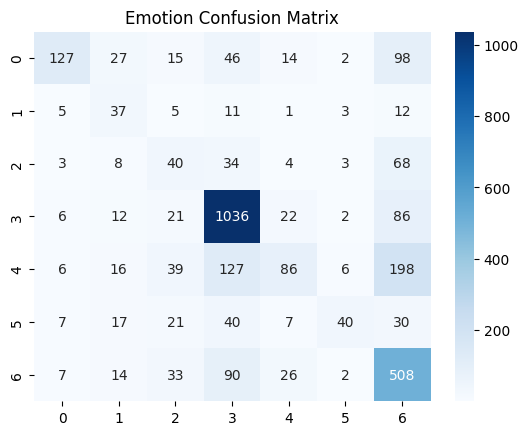

In [ ]:


y_true, y_pred = [], []
with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs['emotion'], dim=1).cpu()
        y_pred.extend(preds)
        y_true.extend(targets['emotion'])

print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Emotion Confusion Matrix")
plt.show()


In [ ]:

def visualize_landmarks(img, gt_landmarks, pred_landmarks, heatmap=None, alpha=0.5):
    """
    Visualize ground-truth (green) and predicted (red) landmarks on an image,
    optionally overlaying a heatmap directly on the image.

    Args:
        img (Tensor): Image tensor of shape [3, H, W], values in [0,1] or [0,255]
        gt_landmarks (Tensor): Ground truth landmarks [num_landmarks, 2]
        pred_landmarks (Tensor): Predicted landmarks [num_landmarks, 2]
        heatmap (Tensor, optional): Heatmap to overlay [H, W] or [num_landmarks, H, W]
        alpha (float): Transparency of heatmap overlay
    """
    # Convert image to HWC and numpy, ensure float in [0,1]
    img_np = img.permute(1, 2, 0).cpu().numpy()
    if img_np.max() > 1.0:
        img_np = img_np / 255.0

    # Convert landmarks to numpy
    gt_landmarks_np = gt_landmarks.cpu().numpy()
    pred_landmarks_np = pred_landmarks.cpu().numpy()

    # Overlay heatmap if provided
    if heatmap is not None:
        heatmap = heatmap.cpu()
        if heatmap.dim() == 3:  # [num_landmarks, H, W]
            heatmap = heatmap.sum(0)  # sum over landmarks
        heatmap = heatmap / (heatmap.max() + 1e-6)  # normalize to [0,1]
        heatmap_color = plt.get_cmap('jet')(heatmap)[..., :3]  # HxWx3
        # Combine image and heatmap
        img_np = (1 - alpha) * img_np + alpha * heatmap_color
        img_np = np.clip(img_np, 0, 1)  # ensure valid range

    plt.figure(figsize=(5, 5))
    plt.imshow(img_np)
    plt.scatter(gt_landmarks_np[:, 0], gt_landmarks_np[:, 1], c='lime', s=40, marker='o', label='GT')
    plt.scatter(pred_landmarks_np[:, 0], pred_landmarks_np[:, 1], c='red', s=40, marker='x', label='Pred')
    plt.legend()
    plt.axis('off')
    plt.show()


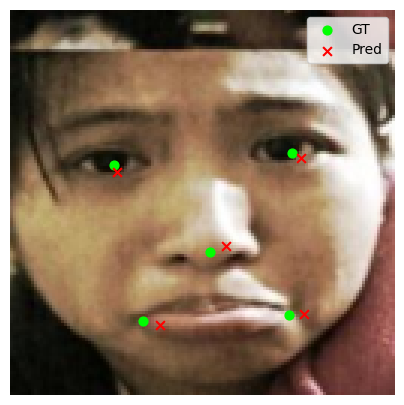

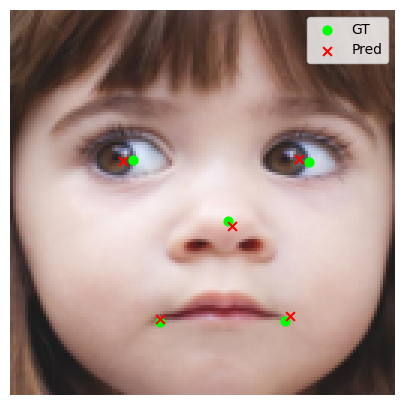

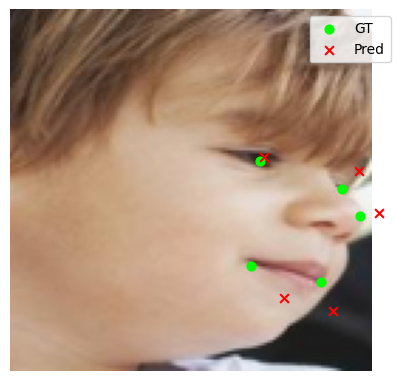

In [ ]:
model.eval()
with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs['landmarks'].cpu()

        # Visualize first 3 examples from this batch
        for i in range(3):
            visualize_landmarks(
                imgs[i],
                targets['landmarks'][i],
                preds[i]
            )
        break  # visualize only the first batch for now


#### Attempt 2

In [154]:
dataset = RAFDataset(df_train, transform=train_transform)

In [155]:
train_loader = DataLoader(dataset, batch_size=32, sampler=sampler)

# Test: fetch one batch
for images, targets in train_loader:
    print(images.shape)
    print(targets)
    break

torch.Size([32, 3, 128, 128])
{'emotion': tensor([3, 5, 5, 5, 0, 5, 3, 6, 4, 2, 0, 4, 2, 0, 2, 1, 5, 6, 3, 6, 1, 0, 4, 5,
        2, 1, 1, 4, 5, 6, 4, 6]), 'race': tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0,
        0, 2, 0, 0, 0, 0, 2, 0]), 'gender': tensor([0, 0, 0, 1, 2, 1, 0, 1, 1, 1, 0, 2, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 2, 1, 0, 0, 0, 0]), 'age': tensor([3, 2, 3, 2, 0, 2, 0, 1, 2, 2, 1, 0, 2, 2, 3, 2, 3, 2, 1, 1, 2, 1, 2, 2,
        2, 2, 0, 4, 2, 3, 1, 1]), 'landmarks': tensor([[[ 26.2322,  50.5624],
         [ 78.1023,  47.0629],
         [ 39.4073,  72.9908],
         [ 26.9145,  93.7639],
         [ 82.8883,  90.1357]],

        [[ 33.6946,  47.3557],
         [ 98.7117,  45.6917],
         [ 63.8344,  66.6633],
         [ 40.1530,  97.6210],
         [ 95.2668,  94.2919]],

        [[ 34.9593,  50.0163],
         [ 94.2603,  43.6253],
         [ 67.9824,  71.6766],
         [ 51.4713,  96.5320],
         [ 97.0510,  95.82

In [163]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
model_att2 = MultiTaskCNN_v2().to(device)



def make_weighted_loss(column_name):
    """Create CrossEntropyLoss with class weights based on inverse frequency."""
    class_counts = df_train[column_name].value_counts().sort_index().values
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
    class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize
    print(f"\nWeights for {column_name}:", class_weights)
    return nn.CrossEntropyLoss(weight=class_weights.to(device))

criterion_emotion = nn.CrossEntropyLoss()  # baseline — unweighted
criterion_race    = make_weighted_loss('race')
criterion_gender  = make_weighted_loss('gender')
criterion_age     = make_weighted_loss('age')
criterion_land    = nn.MSELoss()

# --- 3. Weighted sampler for EMOTION balancing ---
emotion_counts = df_train['emotion'].value_counts().sort_index().values
emotion_weights = 1. / torch.tensor(emotion_counts, dtype=torch.float)
sample_weights = emotion_weights[df_train['emotion'].values]  # it is already 0 based

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# criterion_cls = nn.CrossEntropyLoss()  # for emotion, race, gender, age
criterion_land = nn.MSELoss()          # for landmarks

optimizer = torch.optim.Adam(model_att2.parameters(), lr=1e-3)


Using device: cuda

Weights for race: tensor([0.1921, 1.8641, 0.9438])

Weights for gender: tensor([0.3594, 0.2715, 2.3691])

Weights for age: tensor([0.8388, 0.4957, 0.1648, 0.5605, 2.9403])


In [ ]:


num_epochs = 20
stop_training = False

for epoch in range(num_epochs):
    print("Starting epoch", epoch+1)
    if stop_training:
        print("Training stopped manually.")
        break

    model_att2.train()
    total_loss = 0.0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()

        emotions = targets['emotion'].to(device)
        races    = targets['race'].to(device)
        genders  = targets['gender'].to(device)
        ages     = targets['age'].to(device)
        heatmaps = targets['landmarks'].to(device)

        outputs = model_att2(imgs)

        loss = criterion_emotion(outputs['emotion'], emotions)
        loss += criterion_race(outputs['race'], races)
        loss += criterion_gender(outputs['gender'], genders)
        loss += criterion_age(outputs['age'], ages)
        loss += criterion_land(outputs['landmarks'], heatmaps)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if keyboard.is_pressed('s'):
            stop_training = True
            print("Training will be stopped after this epoch.")

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")


Starting epoch 1
Epoch [1/20], Loss: 125.8293
Starting epoch 2
Epoch [2/20], Loss: 51.0839
Starting epoch 3
Epoch [3/20], Loss: 40.5034
Starting epoch 4
Epoch [4/20], Loss: 32.3837
Starting epoch 5
Epoch [5/20], Loss: 27.9852
Starting epoch 6
Epoch [6/20], Loss: 24.5740
Starting epoch 7
Epoch [7/20], Loss: 20.1697
Starting epoch 8
Epoch [8/20], Loss: 19.1894
Starting epoch 9
Epoch [9/20], Loss: 16.8401
Starting epoch 10
Epoch [10/20], Loss: 16.8879
Starting epoch 11
Epoch [11/20], Loss: 13.6819
Starting epoch 12
Epoch [12/20], Loss: 13.7488
Starting epoch 13
Epoch [13/20], Loss: 12.2069
Starting epoch 14
Training will be stopped after this epoch.
Epoch [14/20], Loss: 11.6007
Starting epoch 15
Training stopped manually.


In [152]:
def heatmap_to_coords(heatmaps):
    """
    Convert predicted heatmaps to (x, y) coordinates using argmax.
    heatmaps: [batch, num_landmarks, H, W]
    Returns: [batch, num_landmarks, 2]
    """
    coords = []
    for hmap in heatmaps:  # loop over batch
        lm_coords = []
        for i in range(hmap.shape[0]):  # loop over landmarks
            y, x = torch.nonzero(hmap[i] == hmap[i].max(), as_tuple=True)
            lm_coords.append([x.float().mean(), y.float().mean()])  # average if multiple max
        coords.append(lm_coords)
    return torch.tensor(coords, device=heatmaps.device)


In [ ]:


# --- 1. Prepare test dataset and loader ---
test_dataset = RAFDataset(df_test, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- 2. Set model to evaluation mode ---
model_att2.eval()

# --- 3. Metrics accumulators ---
total = 0
correct_emotion = 0
correct_race = 0
correct_gender = 0
correct_age = 0
total_landmarks_loss = 0.0

criterion_land = nn.MSELoss()

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = imgs.to(device)

        outputs = model_att2(imgs)

        # Move targets to device
        emotions = targets['emotion'].to(device)
        races    = targets['race'].to(device)
        genders  = targets['gender'].to(device)
        ages     = targets['age'].to(device)
        landmarks = targets['landmarks'].to(device)

        # --- Classification accuracies ---
        pred_emotion = outputs['emotion'].argmax(dim=1)
        pred_race    = outputs['race'].argmax(dim=1)
        pred_gender  = outputs['gender'].argmax(dim=1)
        pred_age     = outputs['age'].argmax(dim=1)

        correct_emotion += (pred_emotion == emotions).sum().item()
        correct_race    += (pred_race == races).sum().item()
        correct_gender  += (pred_gender == genders).sum().item()
        correct_age     += (pred_age == ages).sum().item()

        total += imgs.size(0)

        # --- Landmark MSE ---
        pred_landmarks = outputs['landmarks_heatmap']  # if using heatmap, you may need argmax to coordinates
        # For simple regression (coords), use:
        pred_landmarks_coords = heatmap_to_coords(outputs['landmarks_heatmap'])
        total_landmarks_loss += criterion_land(pred_landmarks_coords, landmarks).item() * imgs.size(0)

# --- 4. Print results ---
print(f"Emotion Accuracy: {correct_emotion / total:.4f}")
print(f"Race Accuracy:    {correct_race / total:.4f}")
print(f"Gender Accuracy:  {correct_gender / total:.4f}")
print(f"Age Accuracy:     {correct_age / total:.4f}")
print(f"Landmarks MSE:    {total_landmarks_loss / total:.4f}")


KeyError: 'landmarks_heatmap'

In [168]:
eval_model(model_att2, df_test, test_transform)

Emotion Accuracy: 0.5655
Race Accuracy:    0.7813
Gender Accuracy:  0.7243
Age Accuracy:     0.5153
Landmarks MSE:    26.863384


#### Visual

In [224]:
def visualize_heatmap(img, heatmap):
    # plt.imshow(img.permute(1,2,0).cpu())
    
    # Remove all singleton dimensions
    heatmap = heatmap.squeeze()
    
    # Now heatmap should be [num_landmarks,H,W] or [H,W]
    if heatmap.dim() == 3:  # sum over landmarks
        summed_heatmap = heatmap.sum(0)
    else:
        summed_heatmap = heatmap  # already 2D
        return summed_heatmap
    
    plt.imshow(summed_heatmap.cpu(), alpha=0.5, cmap='jet')
    plt.show()


In [260]:

def visualize_heatmap_on_image(img, heatmap, alpha=0.5):
    """
    Overlay heatmap on original image.
    
    Args:
        img (Tensor): [3,H,W], values in [0,1] or [0,255]
        heatmap (Tensor): [num_landmarks,H,W] or [H,W]
        alpha (float): transparency
    """
    # Convert image to HWC numpy
    img_np = img.permute(1,2,0).cpu().numpy()
    if img_np.max() > 1.0:
        img_np = img_np / 255.0

    # Prepare heatmap
    heatmap = heatmap.squeeze()
    if heatmap.dim() == 3:
        heatmap = heatmap.sum(0)  # sum over landmarks
    heatmap = heatmap.cpu().numpy()
    heatmap = heatmap / (heatmap.max() + 1e-6)  # normalize to [0,1]

    # Convert heatmap to RGB
    heatmap_rgb = plt.get_cmap('jet')(heatmap)[..., :3]

    # Overlay
    overlay = (1-alpha) * img_np + alpha * heatmap_rgb
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

In [225]:
def points_to_heatmap(landmarks, heatmap_size=32, sigma=2.0, img_size=128):
    """
    landmarks: [B, num_landmarks, 2] in pixel coords (0..IMG_SIZE)
    returns: [B, num_landmarks, heatmap_size, heatmap_size]
    """
    batch_size, num_landmarks, _ = landmarks.shape
    device = landmarks.device

    y = torch.arange(heatmap_size, device=device).view(1, 1, heatmap_size, 1)
    x = torch.arange(heatmap_size, device=device).view(1, 1, 1, heatmap_size)

    heatmaps = []
    for b in range(batch_size):
        single_heatmaps = []
        for n in range(num_landmarks):
            # normalize coordinates to heatmap size
            mu_x = landmarks[b, n, 0] / img_size * heatmap_size
            mu_y = landmarks[b, n, 1] / img_size * heatmap_size
            g = torch.exp(-((x - mu_x)**2 + (y - mu_y)**2)/(2*sigma**2))
            single_heatmaps.append(g)
        single_heatmaps = torch.stack(single_heatmaps)  # [num_landmarks,H,W]
        heatmaps.append(single_heatmaps)

    heatmaps = torch.stack(heatmaps)  # [B,num_landmarks,H,W]
    return heatmaps


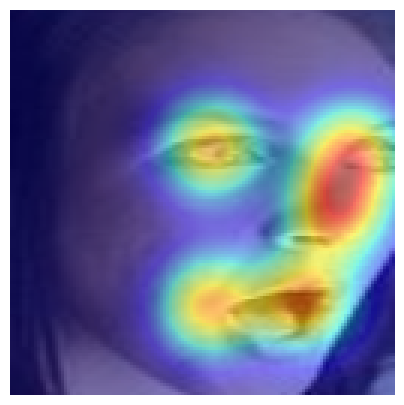

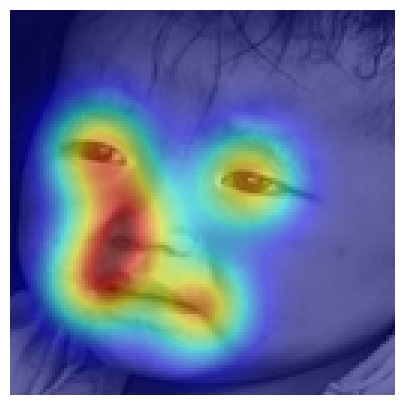

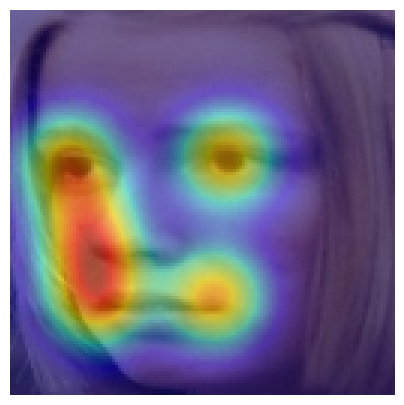

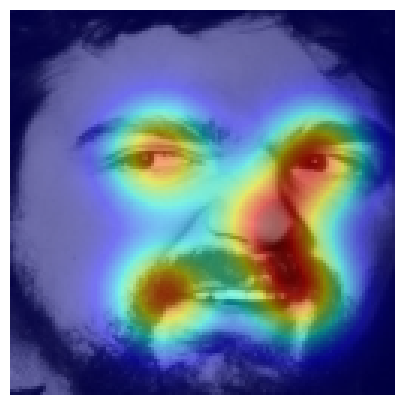

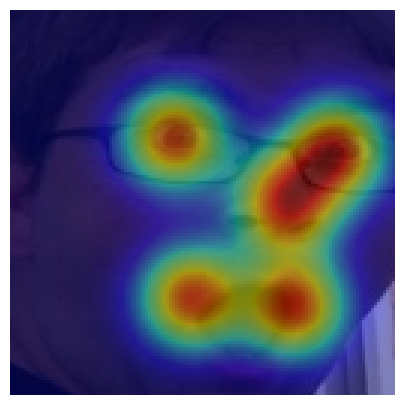

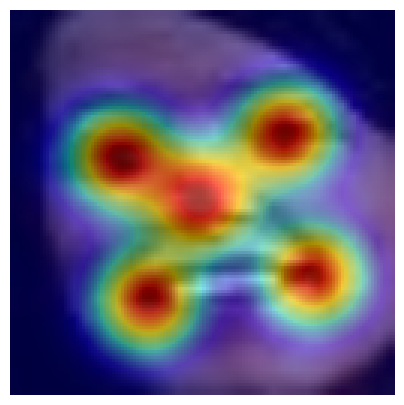

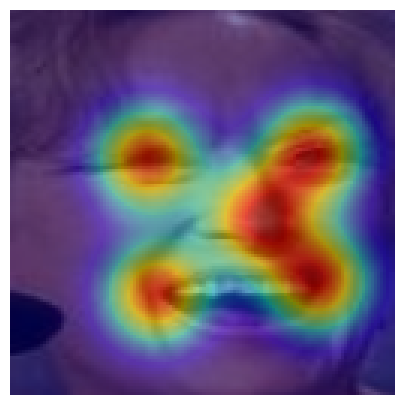

In [274]:
model_att2.eval()
with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = imgs.to(device)
        outputs = model_att2(imgs)
        preds = outputs['landmarks'].cpu()

        heatmaps = points_to_heatmap(preds, heatmap_size=128, sigma=12.0, img_size=128)
        for i in range(3,10): visualize_heatmap_on_image(imgs[i].cpu(), heatmaps[i])
        break


In [280]:
def points_to_heatmap(landmarks, heatmap_size=64, sigma=5.0, img_size=128):
    num_landmarks = landmarks.shape[0]
    device = landmarks.device

    y = torch.arange(heatmap_size, device=device).view(1, heatmap_size, 1)
    x = torch.arange(heatmap_size, device=device).view(1, 1, heatmap_size)

    heatmaps = []
    for n in range(num_landmarks):
        mu_x = landmarks[n, 0] / img_size * heatmap_size
        mu_y = landmarks[n, 1] / img_size * heatmap_size
        g = torch.exp(-((x - mu_x)**2 + (y - mu_y)**2)/(2*sigma**2))
        heatmaps.append(g)
    return torch.stack(heatmaps)  # [num_landmarks,H,W]

In [282]:
def overlay_heatmap_cv2(frame, heatmaps, alpha=0.5):
    """
    frame: HxWx3 BGR
    heatmaps: [num_landmarks,H,W] or [H,W]
    """
    heatmaps = heatmaps.squeeze()
    if heatmaps.dim() == 3:
        heatmap_sum = heatmaps.sum(0)
    else:
        heatmap_sum = heatmaps

    heatmap_sum = heatmap_sum.cpu().numpy()
    heatmap_sum = heatmap_sum / (heatmap_sum.max() + 1e-6)

    # Resize heatmap to frame size
    heatmap_sum = cv2.resize(heatmap_sum, (frame.shape[1], frame.shape[0]))

    # Convert to color
    heatmap_color = cv2.applyColorMap((heatmap_sum*255).astype(np.uint8), cv2.COLORMAP_JET)

    # Overlay
    overlay = cv2.addWeighted(frame, 1-alpha, heatmap_color, alpha, 0)
    return overlay


In [296]:


cap = cv2.VideoCapture(0)


model_att2.eval()
with torch.no_grad():
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Preprocess frame: resize and convert to tensor
        img = cv2.resize(frame, (128,128))
        img_tensor = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).float() / 255.0
        img_tensor = img_tensor.to(device)

        # Predict landmarks
        outputs = model_att2(img_tensor)
        preds = outputs['landmarks'][0].cpu()  # [num_landmarks,2]

        # Generate heatmaps
        heatmaps = points_to_heatmap(preds, heatmap_size=128, sigma=8.0, img_size=128)

        # Overlay heatmap
        overlay = overlay_heatmap_cv2(frame, heatmaps, alpha=0.5)
        
        
        #visualize predicted classes
        emotion_idx = outputs['emotion'].argmax(dim=1).item()
        race_idx    = outputs['race'].argmax(dim=1).item()
        gender_idx  = outputs['gender'].argmax(dim=1).item()
        age_idx     = outputs['age'].argmax(dim=1).item()
        cv2.putText(overlay, f"Emotion: {emotion_label_to_text(emotion_idx)}", (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
        cv2.putText(overlay, f"Race: {race_label_to_text(race_idx)}", (10,70), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
        cv2.putText(overlay, f"Gender: {gender_label_to_text(gender_idx)}", (10,110), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
        cv2.putText(overlay, f"Age: {age_label_to_text(age_idx)}", (10,150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

        # Show in OpenCV window
        cv2.imshow("Camera Heatmap Overlay", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

#### another attempt

In [27]:
class_counts = df_train['emotion'].value_counts().sort_index().values
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = weights[df_train['emotion'].values]  
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
dataset = RAFDataset(df_train, transform=train_transform)
dataloader = DataLoader(dataset, batch_size=32, sampler=sampler)

In [28]:
last_model = MultiTaskCNN_v3().to(device)
classifier_criterion = nn.CrossEntropyLoss()
landmark_criterion = nn.MSELoss()
optimizer = torch.optim.Adam(last_model.parameters(), lr=1e-3)

In [30]:
stop_training = False
last_model.train()
epochs = 10
for epoch in range(epochs):
    if stop_training:
        print("Training stopped manually.")
        break
    print(f"Epoch {epoch+1}/{epochs}")
    total_loss = 0.0
    for imgs, targets in dataloader:
        imgs = imgs.to(device)
        emotions = targets['emotion'].to(device)
        races    = targets['race'].to(device)
        genders  = targets['gender'].to(device)
        ages     = targets['age'].to(device)
        landmarks = targets['landmarks'].to(device)
        
        optimizer.zero_grad()
        outputs = last_model(imgs)
        
        loss_emotion = classifier_criterion(outputs['emotion'], emotions)
        loss_race    = classifier_criterion(outputs['race'],    races)
        loss_gender  = classifier_criterion(outputs['gender'],  genders)
        loss_age     = classifier_criterion(outputs['age'],     ages)
        loss_land    = landmark_criterion(outputs['landmarks'], landmarks)
        
        loss = loss_emotion + loss_race +  loss_gender + loss_age + loss_land
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        if keyboard.is_pressed('s'):
            stop_training = True
            print("Training will be stopped after this epoch.")
    if epoch % 4 == 0:
        eval_model(last_model, df_test, test_transform)
        
    print(f"Total loss: {total_loss:.4f}")

Epoch 1/10
Emotion Accuracy: 0.3722
Race Accuracy:    0.7663
Gender Accuracy:  0.6196
Age Accuracy:     0.3374
Landmarks MSE:    53.446644
Total loss: 33845.8293
Epoch 2/10
Total loss: 91668.5833
Epoch 3/10
Total loss: 66333.5745
Epoch 4/10
Total loss: 65603.9946
Epoch 5/10
Emotion Accuracy: 0.0528
Race Accuracy:    0.7663
Gender Accuracy:  0.4071
Age Accuracy:     0.5417
Landmarks MSE:    168.609894
Total loss: 67116.5978
Epoch 6/10
Total loss: 66956.7383
Epoch 7/10
Total loss: 67027.0603
Epoch 8/10
Total loss: 65367.4192
Epoch 9/10
Emotion Accuracy: 0.1558
Race Accuracy:    0.7663
Gender Accuracy:  0.5280
Age Accuracy:     0.5417
Landmarks MSE:    167.094238
Total loss: 66408.5767
Epoch 10/10
Total loss: 65625.4253
